# AI-Driven Student Performance Prediction


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_performance.csv")
df.head()

C:\Users\Alok Kumar\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,student_id,gender,attendance_pct,study_hours_per_day,previous_score,assignment_avg,internal_marks,sleep_hours,classes_missed,extracurricular_level,internet_access,parent_education,final_score,performance_category
0,STU10001,Female,81.7,7.05,32.5,62.5,50.7,5.8,6,Medium,Yes,School,24.9,Fail
1,STU10002,Male,65.5,10.28,44.4,89.2,58.7,7.4,5,Low,Yes,School,44.2,Average
2,STU10003,Female,87.0,2.60,89.8,72.4,55.6,6.2,0,Low,Yes,Graduate,39.3,Fail
3,STU10004,Male,89.3,0.50,53.6,76.4,83.4,6.8,3,Medium,Yes,Graduate,28.2,Fail
4,STU10005,Male,54.6,2.59,62.8,68.8,90.5,8.9,8,Low,Yes,School,37.8,Fail


In [3]:
df[["final_score", "performance_category"]].sort_values("final_score")

,final_score,performance_category
2140,4.8,Fail
1879,5.1,Fail
131,6.0,Fail
200,6.1,Fail
1584,6.3,Fail
...,...,...
518,62.6,Good
455,62.8,Good
302,63.6,Good
1756,64.7,Good


In [6]:
df.groupby("performance_category")["final_score"].agg(
    ["min", "max", "count", "mean"]
)

,min,max,count,mean
performance_category,,,,
Average,40.0,54.9,761,45.169382
Fail,4.8,40.0,2200,30.409136
Good,55.2,67.8,39,58.766667


In [2]:
df.shape

(3000, 14)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             3000 non-null   str    
 1   gender                 3000 non-null   str    
 2   attendance_pct         3000 non-null   float64
 3   study_hours_per_day    3000 non-null   float64
 4   previous_score         3000 non-null   float64
 5   assignment_avg         3000 non-null   float64
 6   internal_marks         3000 non-null   float64
 7   sleep_hours            3000 non-null   float64
 8   classes_missed         3000 non-null   int64  
 9   extracurricular_level  3000 non-null   str    
 10  internet_access        3000 non-null   str    
 11  parent_education       3000 non-null   str    
 12  final_score            3000 non-null   float64
 13  performance_category   3000 non-null   str    
dtypes: float64(7), int64(1), str(6)
memory usage: 425.4 KB


In [4]:
df.isnull().sum()

student_id               0
gender                   0
attendance_pct           0
study_hours_per_day      0
previous_score           0
assignment_avg           0
internal_marks           0
sleep_hours              0
classes_missed           0
extracurricular_level    0
internet_access          0
parent_education         0
final_score              0
performance_category     0
dtype: int64

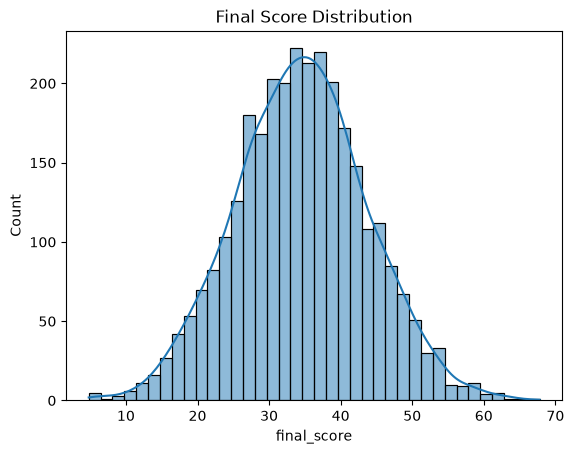

In [5]:
sns.histplot(df["final_score"], kde=True)
plt.title("Final Score Distribution")
plt.show()

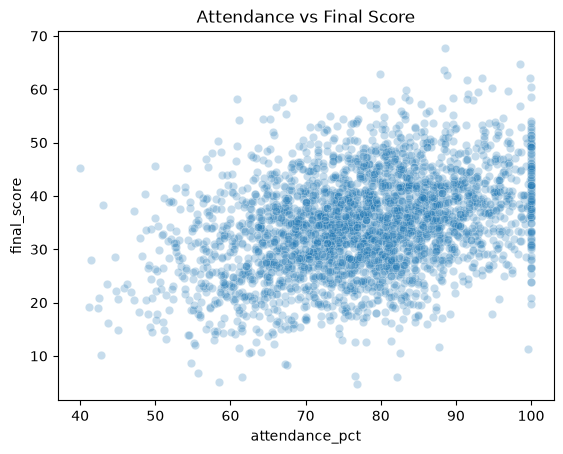

In [6]:
sns.scatterplot(data=df, x="attendance_pct", y="final_score", alpha=0.25)
plt.title("Attendance vs Final Score")
plt.show()

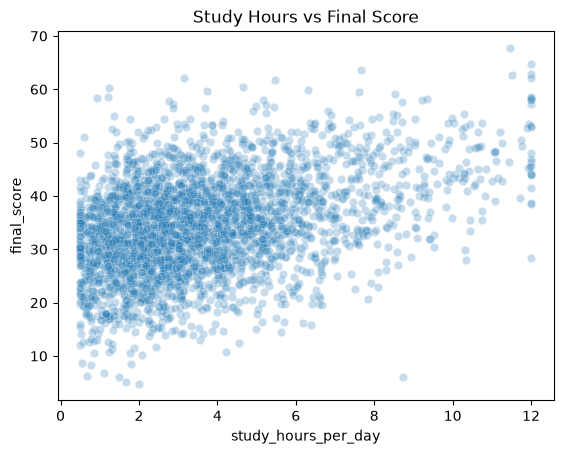

In [7]:
sns.scatterplot(data=df, x="study_hours_per_day", y="final_score", alpha=0.25)
plt.title("Study Hours vs Final Score")
plt.show()

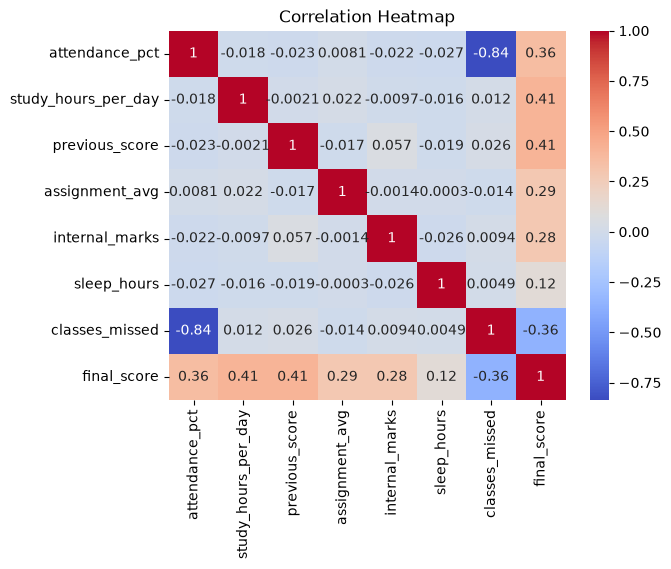

In [8]:
numeric = df.select_dtypes(include="number")
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Next step
Run `python ../train.py` from the project root to train, compare, and save the best model.

In [9]:

import joblib
import pandas as pd
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

In [11]:
target = "final_score"
drop_cols = ["student_id", "performance_category"]
X = df.drop(columns=[target] + drop_cols)
y = df[target]

In [31]:
X.shape

(3000, 11)

In [33]:
y.shape

(3000,)

In [12]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

In [35]:
num_cols

['attendance_pct',
 'study_hours_per_day',
 'previous_score',
 'assignment_avg',
 'internal_marks',
 'sleep_hours',
 'classes_missed']

In [36]:
cat_cols

['gender', 'extracurricular_level', 'internet_access', 'parent_education']

In [37]:
df['gender'].unique()

<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [27]:
df["extracurricular_level"].unique()

<ArrowStringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

In [28]:
df['internet_access'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [29]:
df["parent_education"].unique()

<ArrowStringArray>
['School', 'Graduate', 'Postgraduate']
Length: 3, dtype: str

In [ ]:
cat_cols

['gender', 'extracurricular_level', 'internet_access', 'parent_education']

In [13]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

In [15]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [22]:
X_transformed = preprocessor.fit_transform(X)
X_transformed

array([[ 0.35401516,  1.38419652, -2.52222541, ...,  0.        ,
         0.        ,  1.        ],
       [-1.02546373,  2.73240464, -1.66470226, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.80532615, -0.47324192,  1.60685668, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 1.91231539, -0.13097237, -0.72791225, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.87344857, -0.13514639, -1.42690172, ...,  1.        ,
         0.        ,  0.        ],
       [-0.30166308,  0.29477757,  1.00875229, ...,  0.        ,
         1.        ,  0.        ]], shape=(3000, 18))

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [42]:
results = {}
best_name, best_pipe, best_rmse = None, None, float("inf")

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:16s} MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.3f}")
    if rmse < best_rmse:
        best_name, best_pipe, best_rmse = name, pipe, rmse

Linear Regression MAE=4.346 RMSE=5.490 R2=0.624
Ridge            MAE=4.344 RMSE=5.487 R2=0.625
Random Forest    MAE=4.713 RMSE=5.866 R2=0.571
Gradient Boosting MAE=4.521 RMSE=5.674 R2=0.599


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

grid = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best Alpha: {'model__alpha': 10}
Best CV RMSE: 5.036453892938586


In [44]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Final Ridge Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Final Ridge Results
MAE : 4.344487214871007
RMSE: 5.486913374334167
R2  : 0.6246828865429979


In [51]:
# Best model from GridSearchCV
import pandas as pd

# Student input
student = {
    "gender": "Female",
    "attendance_pct": 81.7,
    "study_hours_per_day": 7.05,
    "previous_score": 32.5,
    "assignment_avg": 62.5,
    "internal_marks": 50.7,
    "sleep_hours": 5.8,
    "classes_missed": 6,
    "extracurricular_level": "Medium",
    "internet_access": "Yes",
    "parent_education": "School"
}

# Convert input into DataFrame
input_data = pd.DataFrame([student])

# Prediction
prediction = best_model.predict(input_data)

print("Predicted final Score:", prediction[0])

Predicted final Score: 22.46566735750337


In [50]:
df.head()

,student_id,gender,attendance_pct,study_hours_per_day,previous_score,assignment_avg,internal_marks,sleep_hours,classes_missed,extracurricular_level,internet_access,parent_education,final_score,performance_category
0,STU10001,Female,81.7,7.05,32.5,62.5,50.7,5.8,6,Medium,Yes,School,24.9,Fail
1,STU10002,Male,65.5,10.28,44.4,89.2,58.7,7.4,5,Low,Yes,School,44.2,Average
2,STU10003,Female,87.0,2.60,89.8,72.4,55.6,6.2,0,Low,Yes,Graduate,39.3,Fail
3,STU10004,Male,89.3,0.50,53.6,76.4,83.4,6.8,3,Medium,Yes,Graduate,28.2,Fail
4,STU10005,Male,54.6,2.59,62.8,68.8,90.5,8.9,8,Low,Yes,School,37.8,Fail


In [52]:
joblib.dump(best_model, "best_ridge_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [53]:
model = joblib.load("best_ridge_model.pkl")

In [54]:
input_data = pd.DataFrame([{
    "gender": "Male",
    "attendance_pct": 85,
    "study_hours_per_day": 4,
    "previous_score": 72,
    "assignment_avg": 78,
    "internal_marks": 75,
    "sleep_hours": 7,
    "classes_missed": 5,
    "extracurricular_level": "Medium",
    "internet_access": "Yes",
    "parent_education": "Graduate"
}])
prediction = model.predict(input_data)

print("Predicted Score:", prediction[0])

Predicted Score: 40.41449685350213
